In [1]:
import pandas as pd
import numpy as np

# LOADING THE DATA
try:
    df = pd.read_excel('processed_100-district-wise-data-160626.xlsx')
    print(f"Successfully loaded preprocessed dataset with {len(df)} families.")
except FileNotFoundError:
    print("Error: 'processed_100-district-wise-data-160626.xlsx' not found. Please run the preprocessing block first.")
    exit()

# Assuming every family is BPL (1) by default, then aggressively filter them out.
df['BPL_Target'] = 1

# DEFINING EXCLUSION CRITERIA CONDITIONS

# DEFINING INCOME BRACKETS (> 1.80 Lakh)
high_income_brackets = [
    '180001-300000',
    '300001-500000',
    '500001-600000',
    '600001-800000',
    '800001-1000000',
    '1000000 AND ABOVE'
]

# Criterion 1: Financial & Tax (Income > 1.8 Lakh OR Pays Income Tax)
condition_high_income = df['familyRange'].isin(high_income_brackets)
condition_tax_payer = df['isIncomeTaxPayee'] >= 1 

# Criterion 2: Employment Exclusions (Government Jobs)
condition_gov_job = df.get('is_Government Employee', pd.Series([0]*len(df))) >= 1

# Criterion 3: High Wage Labourer
condition_high_wage_labourer = (df['isLabour'] >= 1) & (df['labour_wages'] > 15000)

# Criterion 4: Government Pensioner
condition_gov_pensioner = df['isGovPensioner'] >= 1

# Criterion 5: High Electricity Consumption
condition_high_electricity = (df['isElectricityMapping'] >= 1) & (df['electric_annualbillamount'] > 24000)

# Criterion 6: Property & Land (Large Rural Property)
condition_large_rural_property = (df['isRuralProperty'] >= 1) & (df['PanchayatPropertyArea'] > 400)

# Criterion 7: Vehicle & Asset (Owns Four-Wheeler)
condition_four_wheeler = df['isFourWheeler'] >= 1

# Criterion 8: Wealthy Farmer (>5 acres OR >5L earnings)
condition_wealthy_farmer = (df['isFarmer'] >= 1) & ((df['FarmerArea'] > 5) | (df['Farmer_EarningAmount'] > 500000))

# Criterion 9: More than one Private Sector Employee 
condition_private_sector_employee = df['is_Private Sector Employee'] > 1

# EXECUTING THE EXCLUSION ENGINE
# If ANY of the exclusion conditions are True, marking the family as Non-BPL (0)
df.loc[
    condition_high_income |
    condition_tax_payer |
    condition_gov_job |
    condition_high_wage_labourer |
    condition_gov_pensioner |
    condition_high_electricity |
    condition_large_rural_property |
    condition_four_wheeler |
    condition_private_sector_employee |
    condition_wealthy_farmer,
    'BPL_Target'
] = 0

# REVIEWING AND EXPORTING
print("\n--- Categorization Summary ---")
print(df['BPL_Target'].value_counts().rename(index={1: 'BPL Families (1)', 0: 'Non-BPL Families (0)'}))

# Saving to a new file ready for machine learning training
output_file = 'labeled_final_dataset.xlsx'
df.to_excel(output_file, index=False)
print(f"\nExclusion Engine complete! Final labeled data saved to '{output_file}'.")

Successfully loaded preprocessed dataset with 2301 families.

--- Categorization Summary ---
BPL_Target
Non-BPL Families (0)    1198
BPL Families (1)        1103
Name: count, dtype: int64

Exclusion Engine complete! Final labeled data saved to 'labeled_final_dataset.xlsx'.



--- Generating Correlation Matrix ---
Correlation heatmap saved to 'correlation_matrix.png'.

Top Correlations with BPL_Target:
BPL_Target                            1.000000
in_State Government                   0.187405
in_Non-Government Aided               0.041911
is_Unorganised worker                 0.036992
isRuralProperty                       0.010189
is_Unemployed                         0.004243
is_Government Contractual Employee   -0.020008
is_Contractual                       -0.020008
in_Central Government                -0.020008
is_Others                            -0.026340
is_Doctor                            -0.042259
is_Advocate                          -0.044777
in_Non-Government Un-Aided           -0.052737
PanchayatPropertyArea                -0.058165
PenAmt                               -0.104069
Farmer_EarningAmount                 -0.118639
isFarmer                             -0.120443
FarmerArea                           -0.131883
labour_wages             

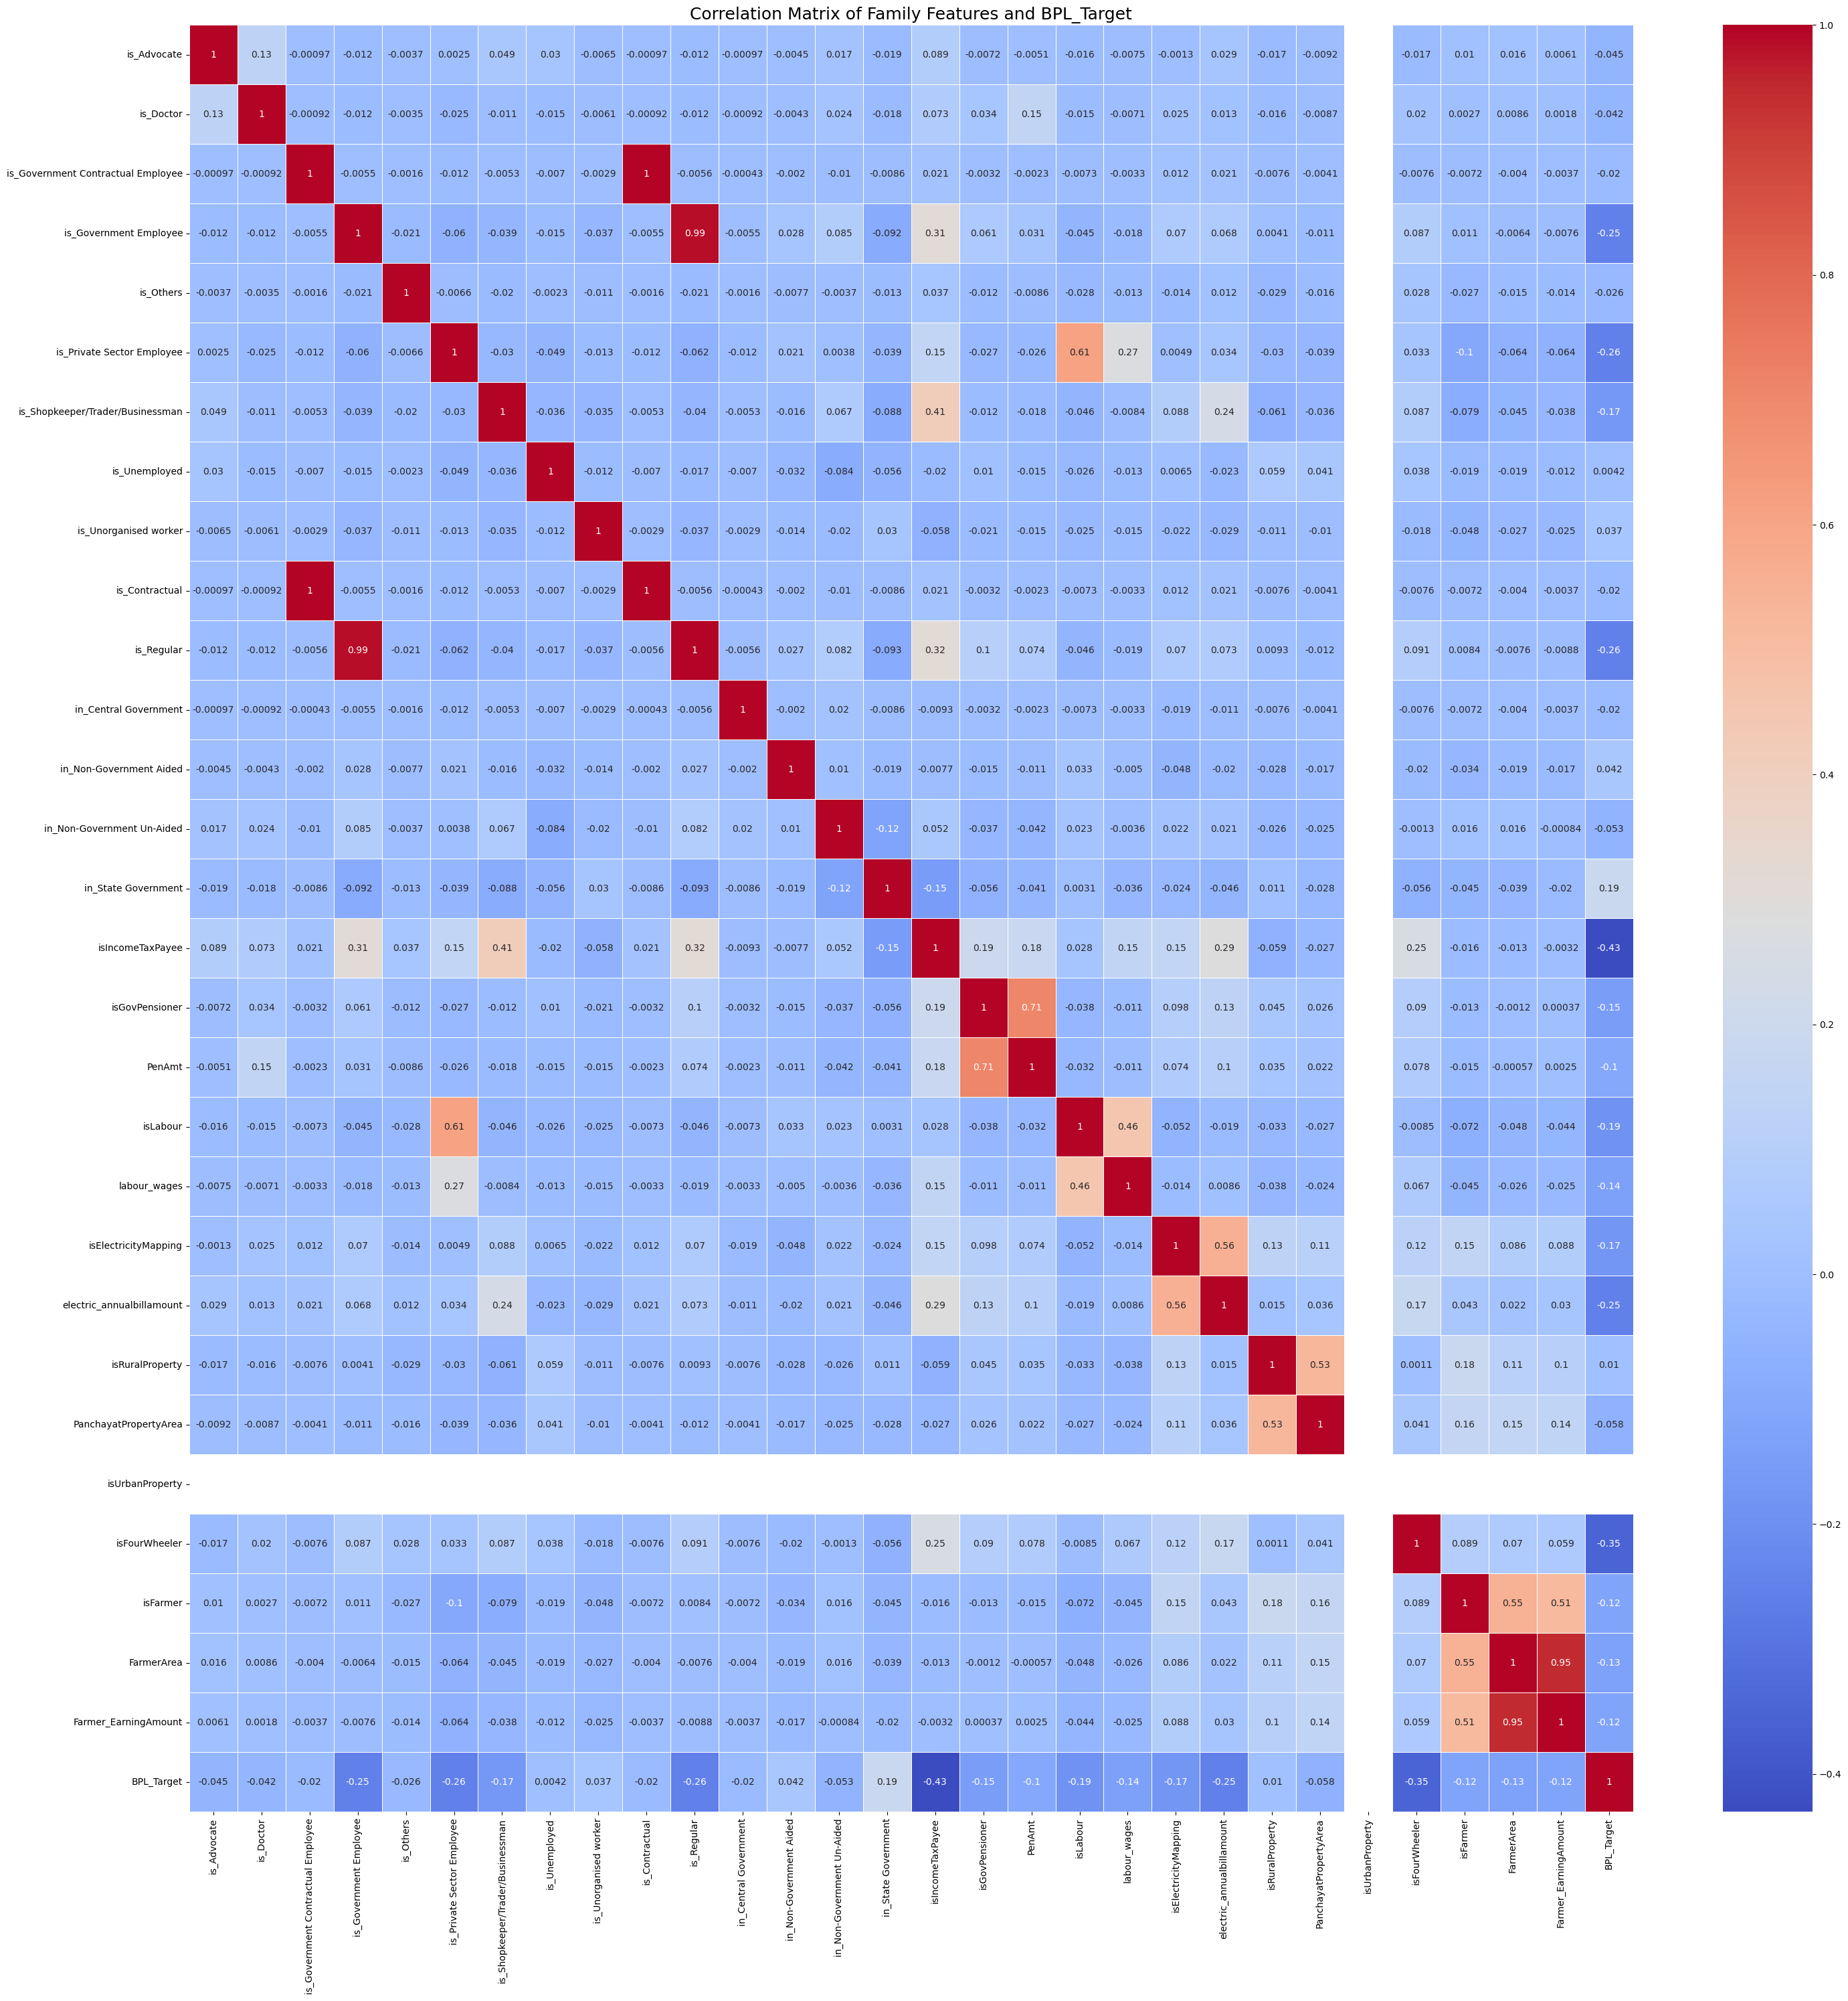

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

# CORRELATION MATRIX GENERATION
print("\n--- Generating Correlation Matrix ---")

# Wanting the model to learn based on jobs, vehicles, and assets, not direct income counts.
income_cols = [col for col in df.columns if col.startswith('in') and any(char.isdigit() for char in col)]

cols_to_exclude = ['hasfamilyid', 'familyRange', 'district', 'blocktown', 'wardvillage', 'r_u', 'is_Child', 'is_Farmer', 'is_Housewife', 'is_Labour', 'is_Pensioner/Retired', 'is_Senior Citizen', 'is_Student'] + income_cols 
# Comment '+ income_cols' and the lines of code above the comment in the 100-Families.ipynb to add the Per Member Salary to the training dataset
num_df = df.drop(columns=[col for col in cols_to_exclude if col in df.columns])

# Ensuring remaining columns are strictly numerical
num_df = num_df.select_dtypes(include=['int64', 'float64'])

# Computing the correlation matrix
corr_matrix = num_df.corr()

# Creating the Heatmap Plot
fig, ax = plt.subplots(figsize=(30,30))

# Optional: Create a mask to hide the upper triangle for better readability
# mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix, 
#    mask=mask, 
    annot=True,            # Set to False if we do not want numbers inside the boxes
    cmap='coolwarm', 
    linewidths=0.5, 
    ax=ax
)

plt.title('Correlation Matrix of Family Features and BPL_Target', fontsize=18)
plt.xticks(rotation=90, fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()

# Saving and exporting the plot
matrix_file = 'correlation_matrix.png'
plt.savefig(matrix_file, dpi=300)
print(f"Correlation heatmap saved to '{matrix_file}'.")

# Printing the highest correlating features with BPL_Target
print("\nTop Correlations with BPL_Target:")
target_corr = corr_matrix['BPL_Target'].sort_values(ascending=False)
print(target_corr)